In [2]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
from scipy import signal
from pathlib import Path

# Đường dẫn file MP3
audio_path = "tunetank-western-cowboy-duel-background-350113(1).mp3"

In [6]:
#Nhiệm vụ A
from pathlib import Path
import librosa
import numpy as np

audio_path = r"D:\SpeechAndAudio\data\lab1\tunetank-western-cowboy-duel-background-350113.mp3"

# Đọc file, giữ nguyên sampling rate
y, sr = librosa.load(audio_path, sr=None, mono=False)

# Kiểm tra số kênh
if y.ndim == 1:
    channels = 1
    duration = len(y) / sr
else:
    channels = y.shape[0]
    duration = y.shape[1] / sr

# File size
file_size_bytes = Path(audio_path).stat().st_size
file_size_mb = file_size_bytes / (1024 ** 2)

print("Sampling rate:", sr, "Hz")
print("Channels:", channels)
print("Duration:", duration, "seconds")
print("File size:", file_size_bytes, "bytes")
print("File size:", file_size_mb, "MB")
print("Shape:", y.shape)
print("Dtype:", y.dtype)
#NyQuist
nyquist = sr / 2
print(f"Nyquist frequency: {nyquist:.2f} Hz")
#xử lý stereo -> mono
if y.ndim == 2:
    y_mono = np.mean(y, axis=0)
else:
    y_mono = y

print("Mono shape:", y_mono.shape)

Sampling rate: 44100 Hz
Channels: 2
Duration: 175.90857142857143 seconds
File size: 5629074 bytes
File size: 5.368303298950195 MB
Shape: (2, 7757568)
Dtype: float32
Nyquist frequency: 22050.00 Hz
Mono shape: (7757568,)


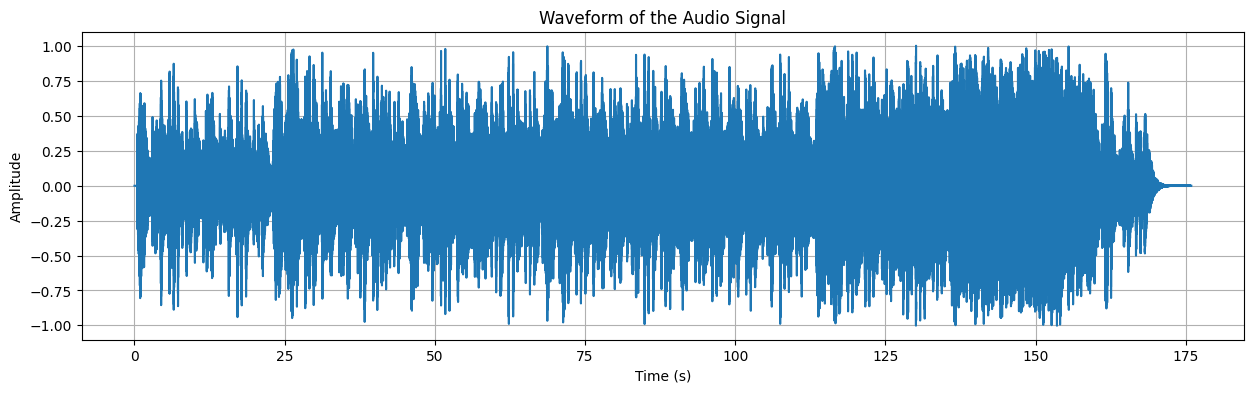

In [7]:
#Nhiệm vụ B
duration = len(y_mono) / sr
time = np.arange(len(y_mono)) / sr

plt.figure(figsize=(15, 4))
plt.plot(time, y_mono)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Waveform of the Audio Signal")
plt.grid(True)
plt.show()

In [8]:
#Tìm peak
peak = np.max(np.abs(y_mono))

print("Peak =", peak)

Peak = 1.003722


In [10]:
#RMS
rms = np.sqrt(np.mean(y_mono ** 2))

print("RMS =", rms)

RMS = 0.19058132


In [11]:
#energy
energy = np.sum(y_mono ** 2)

print("Energy =", energy)

Energy = 281764.47


In [12]:
#Kiểm tra clipping
clipping_samples = np.sum(np.abs(y_mono) >= 1.0)

print("Number of clipping samples:", clipping_samples)

Number of clipping samples: 3


In [13]:
#Chọn 2 mẫu để so sánh
segments = [
    (10, 11),
    (45, 46)
]

for start, end in segments:
    segment = y_mono[int(start*sr):int(end*sr)]

    peak_seg = np.max(np.abs(segment))
    rms_seg = np.sqrt(np.mean(segment**2))
    energy_seg = np.sum(segment**2)

    print(f"\nSegment {start}-{end}s")
    print("Peak:", peak_seg)
    print("RMS:", rms_seg)
    print("Energy:", energy_seg)


Segment 10-11s
Peak: 0.621057
RMS: 0.16360322
Energy: 1180.3811

Segment 45-46s
Peak: 0.66021997
RMS: 0.13716604
Energy: 829.72046


In [14]:
#C1 chọn đoạn 45-46s
start = 45
end = 46

segment = y_mono[int(start*sr):int(end*sr)]

In [15]:
#Hamming
window = np.hamming(len(segment))

windowed_signal = segment * window

In [16]:
#FFT
NFFT = 4096

X = np.fft.rfft(windowed_signal, n=NFFT)

freqs = np.fft.rfftfreq(NFFT, d=1/sr)

magnitude = np.abs(X)

magnitude_db = 20 * np.log10(
    np.maximum(magnitude, 1e-12)
)

In [17]:
#Frequency bin
delta_f = sr / NFFT

print("Frequency bin spacing =", delta_f, "Hz")

Frequency bin spacing = 10.7666015625 Hz


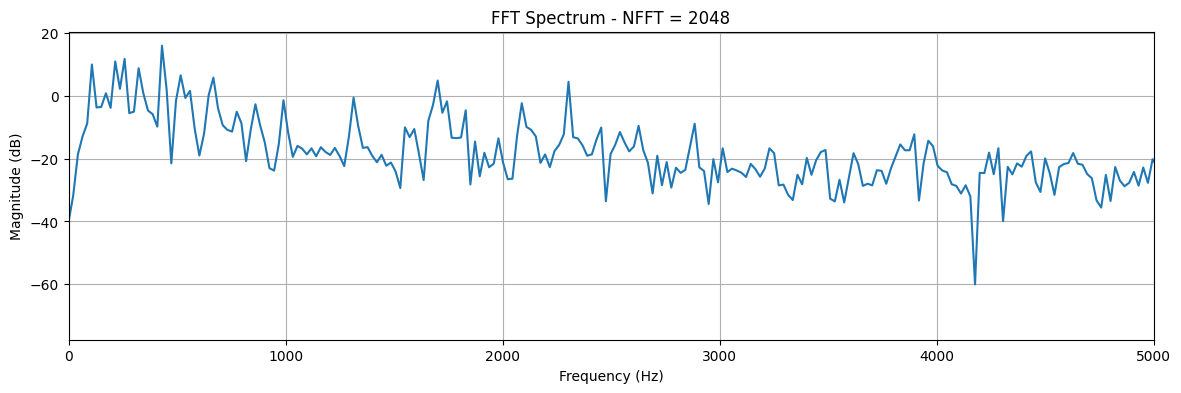

NFFT=2048, Δf=21.533 Hz


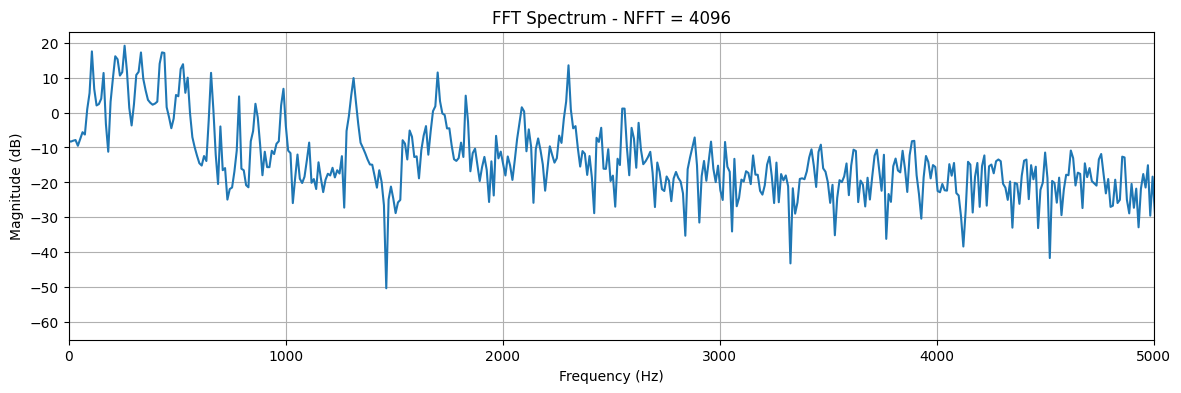

NFFT=4096, Δf=10.767 Hz


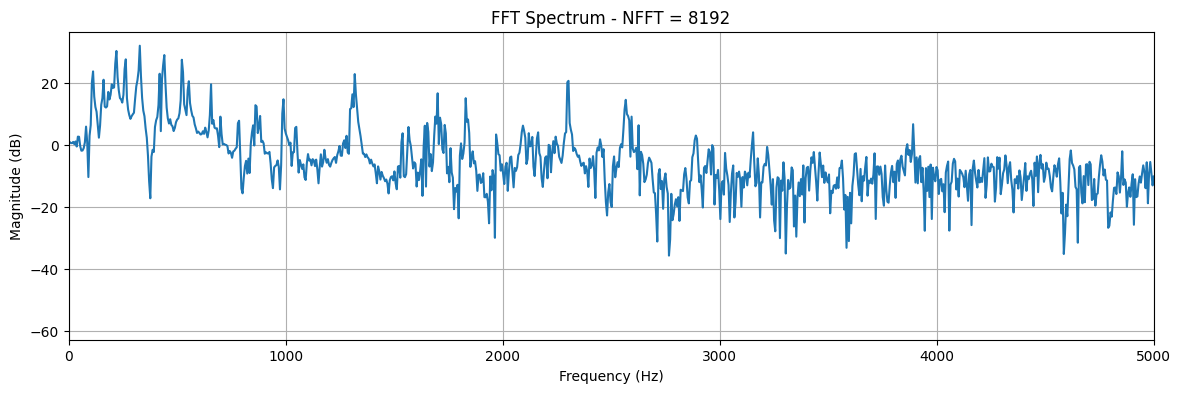

NFFT=8192, Δf=5.383 Hz


In [18]:
#So sánh NFFT
for NFFT in [2048, 4096, 8192]:

    X = np.fft.rfft(windowed_signal, n=NFFT)
    freqs = np.fft.rfftfreq(NFFT, 1/sr)

    magnitude_db = 20 * np.log10(
        np.maximum(np.abs(X), 1e-12)
    )

    plt.figure(figsize=(14, 4))
    plt.plot(freqs, magnitude_db)
    plt.xlim(0, 5000)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude (dB)")
    plt.title(f"FFT Spectrum - NFFT = {NFFT}")
    plt.grid(True)
    plt.show()

    print(
        f"NFFT={NFFT}, Δf={sr/NFFT:.3f} Hz"
    )

In [ ]:
#STFT + SPECTROGRAM
#D1 25ms
frame_length = int(round(0.025 * sr))
hop_length = int(round(0.010 * sr))

print("Frame length:", frame_length)
print("Hop length:", hop_length)


Frame length: 1102
Hop length: 441


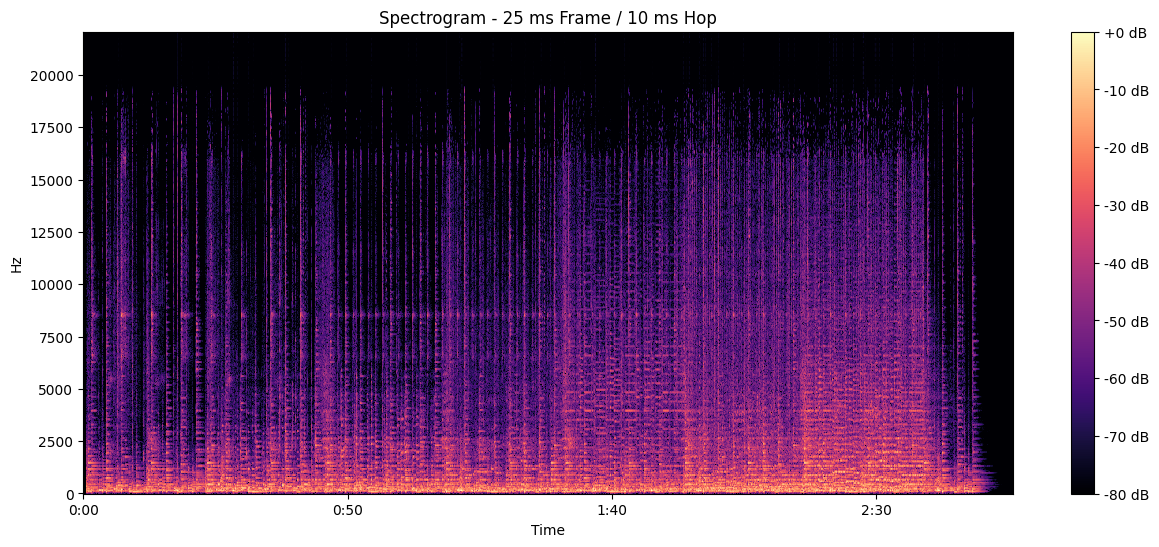

In [21]:
S_complex = librosa.stft(
    y_mono,
    n_fft=2048,
    hop_length=hop_length,
    win_length=frame_length,
    window="hamming"
)

S_mag = np.abs(S_complex)
S_db = librosa.amplitude_to_db(
    S_mag,
    ref=np.max
)
plt.figure(figsize=(15, 6))

librosa.display.specshow(
    S_db,
    sr=sr,
    hop_length=hop_length,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram - 25 ms Frame / 10 ms Hop")
plt.show()

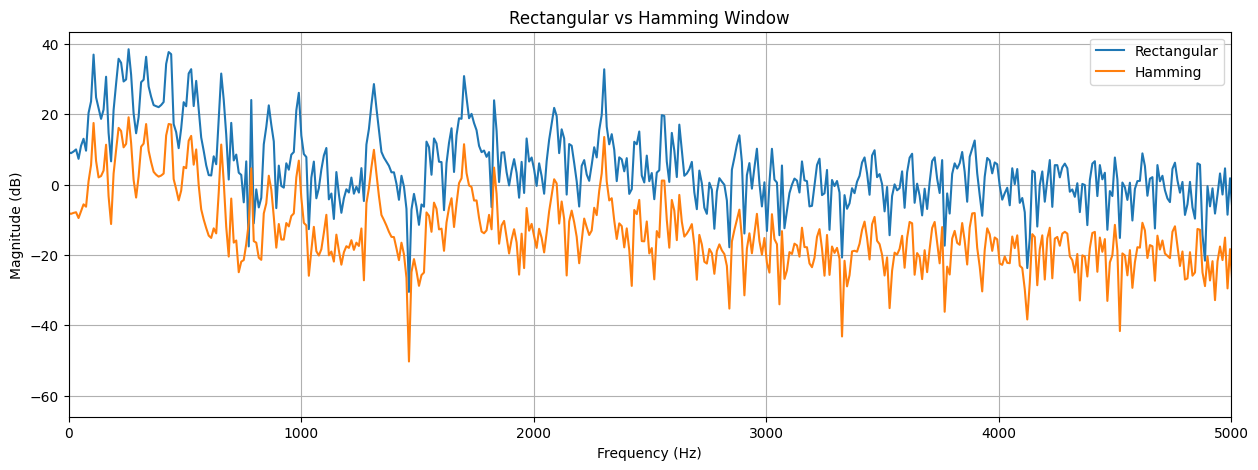

In [23]:
#E. RECTANGULAR VS HAMMING
NFFT = 4096

rect_window = np.ones(len(segment))
hamming_window = np.hamming(len(segment))

X_rect = np.fft.rfft(
    segment * rect_window,
    n=NFFT
)

X_hamming = np.fft.rfft(
    segment * hamming_window,
    n=NFFT
)

freqs = np.fft.rfftfreq(
    NFFT,
    1/sr
)

db_rect = 20 * np.log10(
    np.maximum(np.abs(X_rect), 1e-12)
)

db_hamming = 20 * np.log10(
    np.maximum(np.abs(X_hamming), 1e-12)
)

plt.figure(figsize=(15, 5))

plt.plot(freqs, db_rect, label="Rectangular")
plt.plot(freqs, db_hamming, label="Hamming")

plt.xlim(0, 5000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Rectangular vs Hamming Window")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
#F.1. Low-pass 2 kHz
numtaps = 201
cutoff = 2000

b_lpf = signal.firwin(
    numtaps=numtaps,
    cutoff=cutoff,
    fs=sr,
    window="hamming"
)

print("Number of coefficients:", len(b_lpf))
print("First 10 coefficients:")
print(b_lpf[:10])

Number of coefficients: 201
First 10 coefficients:
[-5.56928888e-05  1.65011438e-05  8.97404129e-05  1.59235324e-04
  2.20091630e-04  2.67507779e-04  2.97028077e-04  3.04853661e-04
  2.88200031e-04  2.45675511e-04]


In [25]:
#F.2. Áp dụng filter
y_lpf = signal.lfilter(
    b_lpf,
    [1.0],
    y_mono
)

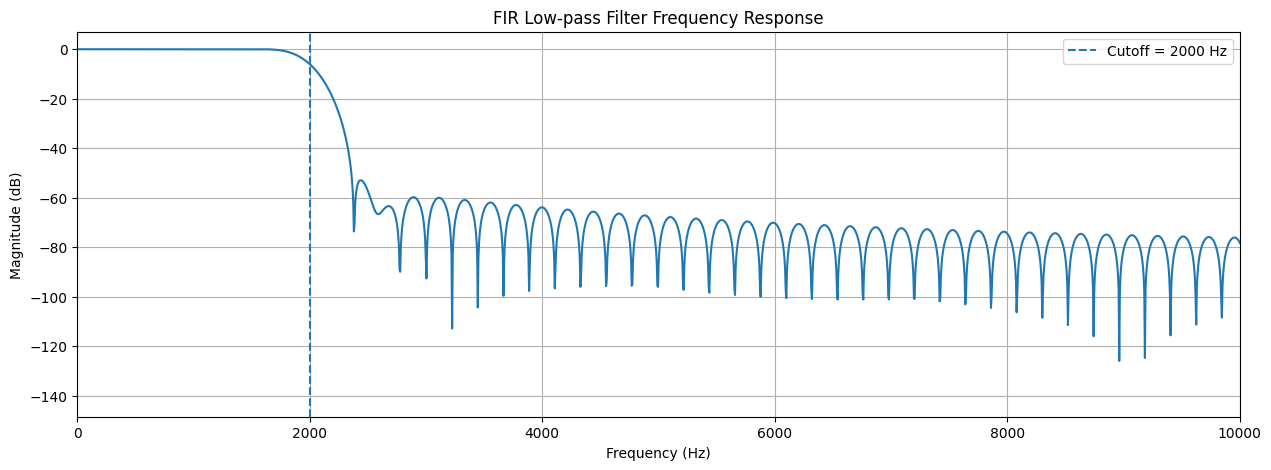

In [26]:
#Frequency response
w, H = signal.freqz(
    b_lpf,
    worN=4096,
    fs=sr
)

plt.figure(figsize=(15, 5))

plt.plot(
    w,
    20 * np.log10(
        np.maximum(np.abs(H), 1e-12)
    )
)

plt.axvline(
    cutoff,
    linestyle="--",
    label="Cutoff = 2000 Hz"
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("FIR Low-pass Filter Frequency Response")
plt.xlim(0, 10000)
plt.grid(True)
plt.legend()
plt.show()

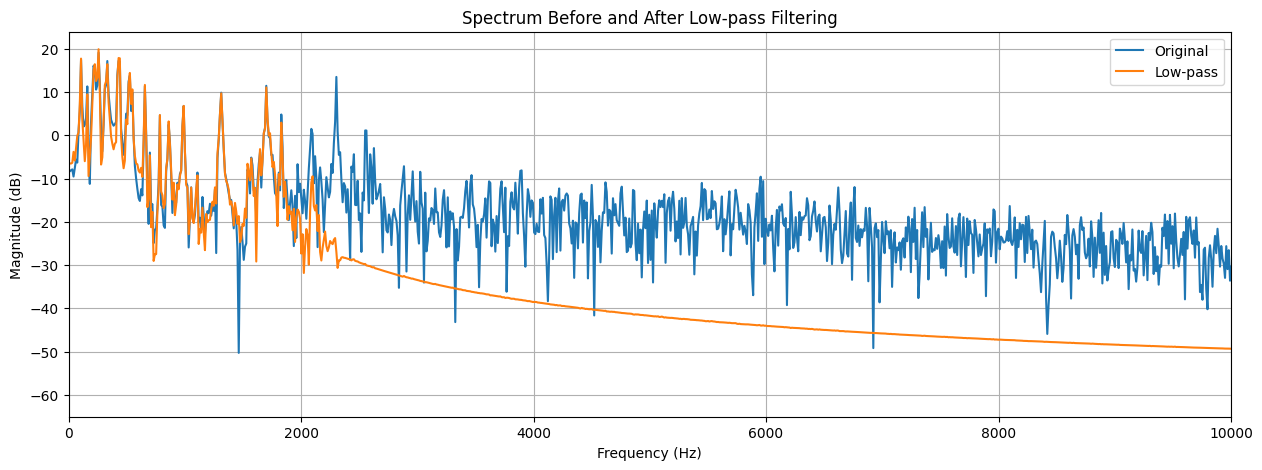

In [27]:
#F.6. So sánh phổ trước/sau
start = 45
end = 46

x_seg = y_mono[
    int(start*sr):
    int(end*sr)
]

y_seg = y_lpf[
    int(start*sr):
    int(end*sr)
]

NFFT = 4096

X = np.fft.rfft(
    x_seg * np.hamming(len(x_seg)),
    n=NFFT
)

Y = np.fft.rfft(
    y_seg * np.hamming(len(y_seg)),
    n=NFFT
)

freqs = np.fft.rfftfreq(
    NFFT,
    1/sr
)

X_db = 20*np.log10(
    np.maximum(np.abs(X), 1e-12)
)

Y_db = 20*np.log10(
    np.maximum(np.abs(Y), 1e-12)
)

plt.figure(figsize=(15, 5))

plt.plot(freqs, X_db, label="Original")
plt.plot(freqs, Y_db, label="Low-pass")

plt.xlim(0, 10000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Spectrum Before and After Low-pass Filtering")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
#lưu audio
sf.write(
    "audio/filtered_lpf_2k.wav",
    y_lpf,
    sr
)

In [30]:
#G.1. Quantization
def quantize_audio(x, bits):

    levels = 2 ** bits

    x_clipped = np.clip(x, -1, 1)

    x_quantized = np.round(
        x_clipped * (levels / 2 - 1)
    ) / (levels / 2 - 1)

    return x_quantized

In [31]:
#SRN
def calculate_snr(x, xq):

    error = xq - x

    signal_power = np.sum(x ** 2)
    noise_power = np.sum(error ** 2)

    snr = 10 * np.log10(
        signal_power / noise_power
    )

    return snr

In [32]:
bits_list = [4, 8, 16]

for bits in bits_list:

    xq = quantize_audio(
        y_mono,
        bits
    )

    snr = calculate_snr(
        y_mono,
        xq
    )

    print(
        f"{bits}-bit: SNR = {snr:.2f} dB"
    )

4-bit: SNR = 13.47 dB
8-bit: SNR = 38.59 dB
16-bit: SNR = 86.50 dB


In [33]:
#Lưu các file
for bits in [4, 8, 16]:

    xq = quantize_audio(
        y_mono,
        bits
    )

    sf.write(
        f"audio/quantized_{bits}bit.wav",
        xq,
        sr,
        subtype="PCM_16"
    )

In [35]:
#Resampling bằng Librosa
y_16k = librosa.resample(
    y_mono,
    orig_sr=sr,
    target_sr=16000
)

y_8k = librosa.resample(
    y_mono,
    orig_sr=sr,
    target_sr=8000
)
sf.write(
    "audio/resampled_16k.wav",
    y_16k,
    16000
)

sf.write(
    "audio/resampled_8k.wav",
    y_8k,
    8000
)

In [36]:
#PCM bitrate
bit_depth = 16
channels = 2

pcm_bitrate = sr * bit_depth * channels

print(
    f"PCM bitrate: {pcm_bitrate:,} bit/s"
)

print(
    f"PCM bitrate: {pcm_bitrate/1000:.1f} kbps"
)

PCM bitrate: 1,411,200 bit/s
PCM bitrate: 1411.2 kbps


In [37]:
#PCM file size
pcm_size_bytes = (
    sr
    * bit_depth
    * channels
    * duration
    / 8
)

pcm_size_mb = (
    pcm_size_bytes
    / (1024 ** 2)
)

print(
    f"Theoretical PCM size: "
    f"{pcm_size_mb:.2f} MB"
)

Theoretical PCM size: 29.59 MB


In [38]:
#Compression ratio
mp3_bitrate = 256  # kbps

compression_ratio = (
    (pcm_bitrate / 1000)
    / mp3_bitrate
)

print(
    f"Compression ratio: "
    f"{compression_ratio:.2f}:1"
)

Compression ratio: 5.51:1


In [39]:
saving = (
    1
    - file_size_bytes / pcm_size_bytes
) * 100

print(
    f"Storage saving: {saving:.2f}%"
)

Storage saving: 81.86%
